<a href="https://colab.research.google.com/github/FareedaAbdelaal/ML-55-9988/blob/main/ML_Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

In [5]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [6]:
# LOAD DATA

df = pd.read_csv('heart.csv')

print(df.head())
print(df.info())


# DEFINE FEATURES AND LABEL

X = df.drop('target', axis=1)
y = df['target']


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5 

In [7]:
# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=101
)

# FEATURE SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
# TRAIN LOGISTIC REGRESSION MODEL

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [9]:
# MODEL COEFFICIENTS

coeff_df = pd.DataFrame(log_model.coef_[0], X.columns, columns=['Coefficient'])
print(coeff_df)


          Coefficient
age         -0.072445
sex         -0.734596
cp           0.893714
trestbps    -0.262495
chol        -0.212186
fbs          0.045964
restecg      0.120366
thalach      0.433264
exang       -0.428235
oldpeak     -0.527225
slope        0.380981
ca          -0.850807
thal        -0.574687


Confusion Matrix:
[[12  3]
 [ 2 14]]


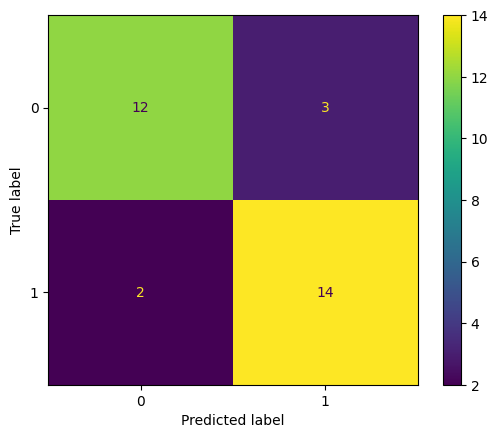

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



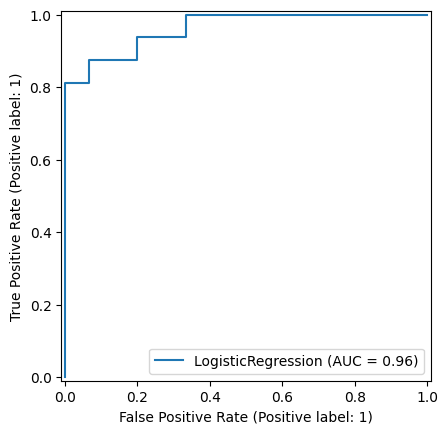

In [10]:
# PREDICTIONS

y_pred = log_model.predict(X_test)


# EVALUATION


# Confusion Matrix (array)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# Confusion Matrix (plot)
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test)
plt.show()


# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


# ROC Curve
RocCurveDisplay.from_estimator(log_model, X_test, y_test)
plt.show()


In [11]:
# NEW PATIENT PREDICTION

patient = [[48.0, 0.0, 2.0, 130.0, 275.0, 0.0, 1.0, 139.0,
            0.0, 0.2, 2.0, 0.0, 2.0]]

# Scale input
patient_scaled = scaler.transform(patient)

# Prediction
prediction = log_model.predict(patient_scaled)
print("Prediction (0 = No Disease, 1 = Disease):", prediction)

# Probability
probability = log_model.predict_proba(patient_scaled)
print("Prediction Probabilities [No Disease, Disease]:")
print(probability)

Prediction (0 = No Disease, 1 = Disease): [1]
Prediction Probabilities [No Disease, Disease]:
[[0.02036527 0.97963473]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Dataset was first split into training (90%) and testing (10%) sets. Then, the features were standardized using a StandardScaler to ensure all variables are on the same scale. The model was trained on the training data and evaluated using the test data.

To assess performance, a confusion matrix, classification report, and ROC curve were used. These metrics show that the model is able to distinguish between patients with and without heart disease with reasonable accuracy.

Finally, the model was used to predict the condition of a new patient. The model outputs both a predicted class (0 = no disease, 1 = disease) and a probability score indicating how confident it is in its prediction. This probability helps in understanding the certainty of the diagnosis.